In [1]:
%pip install mediapipe opencv-python scikit-learn torch pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import mediapipe as mp
import cv2
import numpy as np
import uuid
import os
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

In [4]:
class Model(nn.Module):
    def __init__(self, in_features=120, h1=128, h2=64, out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [5]:
path = '../data.csv'
df = pd.read_csv(path, header=None, names=['type', 'name', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4'])
df = df.drop('name', axis=1)
df

n = 15  # rows per sequence
num_groups = df.shape[0] // n

def make_relative_per_landmark(group):
    for i in range(1, 5):
        x_col, y_col = f'x{i}', f'y{i}'
        x0, y0 = group.iloc[0][[x_col, y_col]]
        group[x_col] = group[x_col] - x0
        group[y_col] = group[y_col] - y0
    coords_array = group[[f'x{i}' for i in range(1, 5)] + [f'y{i}' for i in range(1, 5)]].to_numpy()
    coords_reshaped = coords_array.reshape(len(group), 4, 2)
    
    distances = np.linalg.norm(coords_reshaped, axis=2)
    max_distance = distances.max()
    coords_normalized = coords_reshaped / max_distance if max_distance > 0 else coords_reshaped

    group[[f'x{i}' for i in range(1, 5)] + [f'y{i}' for i in range(1, 5)]] = coords_normalized.reshape(len(group), 8)
    
    return group

groups = [make_relative_per_landmark(df.iloc[i*n:(i+1)*n].copy()) for i in range(num_groups)]
df_rel = pd.concat(groups, ignore_index=True)

df = df_rel

df

,type,x1,y1,x2,y2,x3,y3,x4,y4
0,uppercut_left,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,uppercut_left,-0.273582,0.353050,0.010907,-0.008777,-0.274535,-0.459616,0.225031,-0.089694
2,uppercut_left,-0.379344,0.509464,0.011233,-0.017879,-0.399072,-0.620499,0.390287,-0.093670
3,uppercut_left,-0.459451,0.626103,0.017513,-0.267999,-0.470737,-0.663147,0.460251,-0.051811
4,uppercut_left,-0.524037,0.724863,0.028389,-0.339066,-0.519395,-0.687102,0.491239,-0.045470
...,...,...,...,...,...,...,...,...,...
895,uppercut_right,0.140420,0.007200,0.199693,0.220355,0.043319,0.012151,0.253343,0.014373
896,uppercut_right,0.139553,0.037219,0.196309,0.163264,0.054494,0.021606,0.294226,-0.000322
897,uppercut_right,0.107491,0.061398,0.170432,0.141605,0.054334,0.021778,0.345214,-0.000794
898,uppercut_right,0.085477,0.106275,0.124002,0.116854,0.054317,0.039165,0.361497,0.020373


In [6]:
df['type'] = df['type'].replace('hook_left', 'hook')
df['type'] = df['type'].replace('hook_right', 'hook')
df['type'] = df['type'].replace('jab_left', 'jab')
df['type'] = df['type'].replace('jab_right', 'jab')
df['type'] = df['type'].replace('uppercut_left', 'uppercut')
df['type'] = df['type'].replace('uppercut_right', 'uppercut')
type_mapping = {'hook': 0, 'jab': 1, 'uppercut': 2}
df['type'] = df['type'].map(type_mapping)

X = np.array(df.drop('type', axis=1))
y = np.array(df['type'])

In [7]:
features = ['x1','y1','x2','y2','x3','y3','x4','y4']

n = 15
num_groups = df.shape[0] // n

# Trim the DataFrame to a multiple of n
df_trim = df.iloc[:num_groups * n]

# Convert to NumPy array (only features)
arr = df_trim[features].values  # shape: (num_groups * n, 8)

# Reshape into sequences of 15 rows
grouped = arr.reshape(num_groups, n, len(features))  # shape: (num_groups, 15, 8)

# Flatten each sequence into a single vector
X = grouped.reshape(num_groups, -1)  # shape: (num_groups, 15*8=120)

# Handle labels (assume df['type'] is the label)
y_arr = df_trim['type'].values
y = y_arr.reshape(num_groups, n)[:, 0]  # take first row's label for each sequence

print("X shape:", X.shape)  # should be (num_groups, 120)
print("y shape:", y.shape)  # should be (num_groups,)

X shape: (60, 120)
y shape: (60,)


In [8]:
torch.manual_seed(42)
model = Model()
model

Model(
  (fc1): Linear(in_features=120, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=3, bias=True)
)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# convert y labels to long tensors (64-bit integers)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [11]:
# set criterion of model to measure error (how far off predictions are from data)
criterion = nn.CrossEntropyLoss()

# choose Adam Optimizer
# lr = learning rate (if error doesn't go down after a bunch of epochs, must lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [12]:
# train our model
# epoch = one run through all training data in our network
epochs = 120
losses = []
for i in range(epochs):
  # go forward & get a prediction
  y_pred = model.forward(X_train) # get predicted results

  # measure loss/error, will be high at first
  loss = criterion(y_pred, y_train); # predicted vs training y

  # keep track of losses
  losses.append(loss.detach().numpy())
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 1.0909086465835571
Epoch: 10 and loss: 0.08536437898874283
Epoch: 20 and loss: 0.008326900191605091
Epoch: 30 and loss: 0.0003937122237402946
Epoch: 40 and loss: 4.528472709353082e-05
Epoch: 50 and loss: 1.3605895219370723e-05
Epoch: 60 and loss: 9.86605755315395e-06
Epoch: 70 and loss: 7.735637154837605e-06
Epoch: 80 and loss: 6.635651516262442e-06
Epoch: 90 and loss: 6.1042551351420116e-06
Epoch: 100 and loss: 5.731759301852435e-06
Epoch: 110 and loss: 5.403954219218576e-06


Text(0.5, 0, 'Epoch')

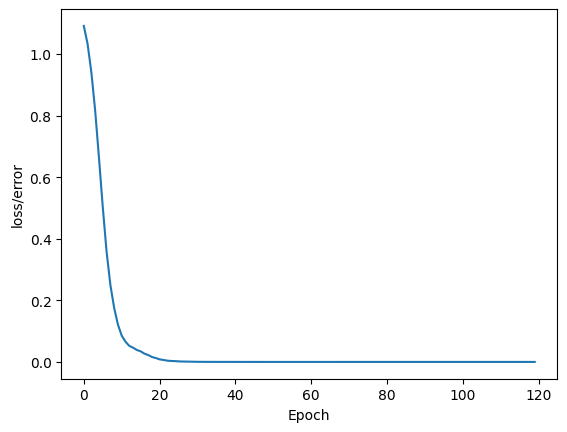

In [13]:
# plot the losses
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("Epoch")

In [14]:
# evaluate model on test data
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)

loss

tensor(4.6164)

In [15]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = "hook"
    elif y_test[i] == 1:
      x = "uppercut"
    elif y_test[i] == 2:
      x = "jab"

    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We got {correct} out of {len(X_test)} correct.')

1.) tensor([-20.6089,  21.0578, -12.4873]) 	 2 	 1
2.) tensor([-13.1217,   1.6212,   5.1210]) 	 2 	 2
3.) tensor([-3.5336, -4.1434,  0.0467]) 	 1 	 2
4.) tensor([-16.9047,   7.2430,   2.0536]) 	 1 	 1
5.) tensor([-13.9699,   3.3173,   1.7888]) 	 0 	 1
6.) tensor([-23.2000, -12.8887,  23.6298]) 	 2 	 2
7.) tensor([-7.4218,  6.8810, -6.9110]) 	 1 	 1
8.) tensor([-12.1523,   2.7178,   0.3528]) 	 1 	 1
9.) tensor([  4.1609,  -7.7782, -10.5487]) 	 0 	 0
10.) tensor([ -8.2200, -17.2038,  18.4604]) 	 2 	 2
11.) tensor([-7.2047,  1.6406, -2.9304]) 	 1 	 1
12.) tensor([-15.1217, -12.2796,  20.0573]) 	 2 	 2
We got 9 out of 12 correct.


In [16]:
torch.save(model.state_dict(), "model_state.pt")